# Comparação fuzzy no conjunto de teste

Este notebook resume os resultados salvos em `output/segmentation/runs/mid_res/fuzzy_comparison`.

O foco é comparar:

- detecção dos óstios;
- Dice score da segmentação arterial;
- impacto do fuzzy threshold e do fuzzy connectedness em relação ao baseline.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from utils.project.notebook_env import configure_notebook_environment
    REPO_ROOT = configure_notebook_environment(chdir_to_src=False)
except Exception:
    current = Path.cwd().resolve()
    REPO_ROOT = next(
        path for path in [current, *current.parents]
        if (path / "src").exists() and (path / "output").exists()
    )

RESULT_ROOT = REPO_ROOT / "output/segmentation/runs/mid_res/fuzzy_comparison"
FIGURE_DIR = REPO_ROOT / "output/segmentation/analysis/fuzzy_comparison_eda/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def save_current_figure(name: str):
    path = FIGURE_DIR / name
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Figura salva em: {path.relative_to(REPO_ROOT)}")

RESULT_ROOT

PosixPath('/home/matheus/workspace/coronary-centerline-detection/output/segmentation/runs/mid_res/fuzzy_comparison')

## Carregamento dos Resultados

A análise usa o `ostios_test_summary.csv` de cada variante como fonte principal, porque esse CSV registra por imagem o método de threshold e o método arterial efetivamente usados.

In [2]:
SUCCESS_LABELS = {
    "both correct",
    "both tolerable",
    "both ostia correct",
    "both ostia tolerable",
}
CORRECT_LABELS = {"both correct", "both ostia correct"}
TOLERABLE_LABELS = {"both tolerable", "both ostia tolerable"}
WRONG_LABELS = {"found but incorrect", "found_but_wrong"}

PREFERRED_ORDER = [
    "normal_rg",
    "th_fuzzy_rg",
    "normal_fc",
    "th_fuzzy_fc",
]

PRETTY_NAMES = {
    "normal_rg": "Normal + RG",
    "th_fuzzy_rg": "Fuzzy threshold + RG",
    "normal_fc": "Normal + FC",
    "th_fuzzy_fc": "Fuzzy threshold + FC",
}


def yes_no_to_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(["yes", "true", "1", "sim"])


def first_existing_value(df: pd.DataFrame, columns: list[str], default: str = "") -> str:
    for column in columns:
        if column in df.columns and not df[column].empty:
            value = df[column].iloc[0]
            if pd.notna(value):
                return str(value)
    return default


def load_variant_run(summary_path: Path) -> tuple[pd.DataFrame, dict]:
    variant = summary_path.parents[2].name
    run_dir = summary_path.parents[1]
    df = pd.read_csv(summary_path)
    df["folder_variant"] = variant
    df["variant_label"] = PRETTY_NAMES.get(variant, variant)
    df["run_timestamp"] = run_dir.name
    df["run_dir"] = str(run_dir.relative_to(REPO_ROOT))
    df["artery_dice"] = pd.to_numeric(df["artery_dice"], errors="coerce")
    df["ostia_detected_bool"] = yes_no_to_bool(df["ostia_detected"])
    df["ostia_success"] = df["ostia_detection_status"].astype(str).isin(SUCCESS_LABELS)
    df["both_correct"] = df["ostia_detection_status"].astype(str).isin(CORRECT_LABELS)
    df["both_tolerable"] = df["ostia_detection_status"].astype(str).isin(TOLERABLE_LABELS)
    df["found_wrong"] = df["ostia_detection_status"].astype(str).isin(WRONG_LABELS)

    summary = {
        "folder_variant": variant,
        "variant_label": PRETTY_NAMES.get(variant, variant),
        "run_timestamp": run_dir.name,
        "run_dir": str(run_dir.relative_to(REPO_ROOT)),
        "n_images": len(df),
        "threshold_mode": first_existing_value(df, ["threshold_mode"], "normal"),
        "artery_method": first_existing_value(
            df,
            ["configured_artery_segmentation_method", "artery_segmentation_method"],
            "",
        ),
        "ostia_detected_rate": df["ostia_detected_bool"].mean(),
        "ostia_success_rate": df["ostia_success"].mean(),
        "both_correct_n": int(df["both_correct"].sum()),
        "both_tolerable_n": int(df["both_tolerable"].sum()),
        "found_wrong_n": int(df["found_wrong"].sum()),
        "not_found_or_error_n": int((~(df["ostia_success"] | df["found_wrong"])).sum()),
        "mean_dice": df["artery_dice"].mean(),
        "median_dice": df["artery_dice"].median(),
        "std_dice": df["artery_dice"].std(),
        "mean_dice_success_ostia": df.loc[df["ostia_success"], "artery_dice"].mean(),
    }
    return df, summary

In [3]:
all_frames = []
summary_rows = []
for summary_path in sorted(RESULT_ROOT.glob("*/*/numeric/ostios_test_summary.csv")):
    variant = summary_path.parents[2].name
    if variant not in PREFERRED_ORDER:
        continue
    df_variant, summary = load_variant_run(summary_path)
    all_frames.append(df_variant)
    summary_rows.append(summary)

if not all_frames:
    raise FileNotFoundError(f"Nenhum ostios_test_summary.csv encontrado em {RESULT_ROOT}")

results_df = pd.concat(all_frames, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)
summary_df["order"] = summary_df["folder_variant"].map({name: idx for idx, name in enumerate(PREFERRED_ORDER)})
summary_df = summary_df.sort_values(["order", "folder_variant"]).drop(columns="order")

print(f"Runs carregados: {summary_df.shape[0]}")
print(f"Linhas por imagem: {results_df.shape[0]}")

Runs carregados: 4
Linhas por imagem: 2800


In [4]:
display(summary_df)

,folder_variant,variant_label,run_timestamp,run_dir,n_images,threshold_mode,artery_method,ostia_detected_rate,ostia_success_rate,both_correct_n,both_tolerable_n,found_wrong_n,not_found_or_error_n,mean_dice,median_dice,std_dice,mean_dice_success_ostia
1,normal_rg,Normal + RG,2026-06-22_10-18-31,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,rg,0.994286,0.808571,60,506,130,4,0.578427,0.652087,0.196185,0.649271
3,th_fuzzy_rg,Fuzzy threshold + RG,2026-06-20_08-33-25,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,rg,0.990000,0.808571,51,515,127,7,0.580936,0.653493,0.195601,0.651245
0,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,fc,0.994286,0.808571,60,506,130,4,0.564721,0.636069,0.193130,0.631494
2,th_fuzzy_fc,Fuzzy threshold + FC,2026-06-20_23-26-14,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,fc,0.990000,0.808571,51,515,127,7,0.562797,0.637484,0.193844,0.627929


## Resumo Geral

A tabela abaixo ordena as variantes por sucesso dos óstios e Dice médio. O sucesso dos óstios considera `both correct` ou `both tolerable` como sucesso.

In [5]:
ranking_df = summary_df.sort_values(
    ["ostia_success_rate", "mean_dice", "mean_dice_success_ostia"],
    ascending=False,
).copy()

ranking_display = ranking_df[[
    "variant_label",
    "threshold_mode",
    "artery_method",
    "n_images",
    "ostia_detected_rate",
    "ostia_success_rate",
    "both_correct_n",
    "both_tolerable_n",
    "found_wrong_n",
    "not_found_or_error_n",
    "mean_dice",
    "median_dice",
    "mean_dice_success_ostia",
]].copy()

for col in ["ostia_detected_rate", "ostia_success_rate"]:
    ranking_display[col] = 100 * ranking_display[col]

In [6]:
display(ranking_display.round({
    "ostia_detected_rate": 1,
    "ostia_success_rate": 1,
    "mean_dice": 4,
    "median_dice": 4,
    "mean_dice_success_ostia": 4,
}))

,variant_label,threshold_mode,artery_method,n_images,ostia_detected_rate,ostia_success_rate,both_correct_n,both_tolerable_n,found_wrong_n,not_found_or_error_n,mean_dice,median_dice,mean_dice_success_ostia
3,Fuzzy threshold + RG,fuzzy,rg,700,99.0,80.9,51,515,127,7,0.5809,0.6535,0.6512
1,Normal + RG,normal,rg,700,99.4,80.9,60,506,130,4,0.5784,0.6521,0.6493
0,Normal + FC,normal,fc,700,99.4,80.9,60,506,130,4,0.5647,0.6361,0.6315
2,Fuzzy threshold + FC,fuzzy,fc,700,99.0,80.9,51,515,127,7,0.5628,0.6375,0.6279


## Detecção dos Óstios

Aqui o status é separado em: ambos corretos, ambos toleráveis, encontrados porém incorretos e não encontrado/erro.

In [7]:
ostia_plot = summary_df.copy()
ostia_plot["variant_label"] = pd.Categorical(
    ostia_plot["variant_label"],
    [PRETTY_NAMES.get(name, name) for name in PREFERRED_ORDER],
    ordered=True,
)
ostia_plot = ostia_plot.sort_values("variant_label")

Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/ostia_status_by_variant.png


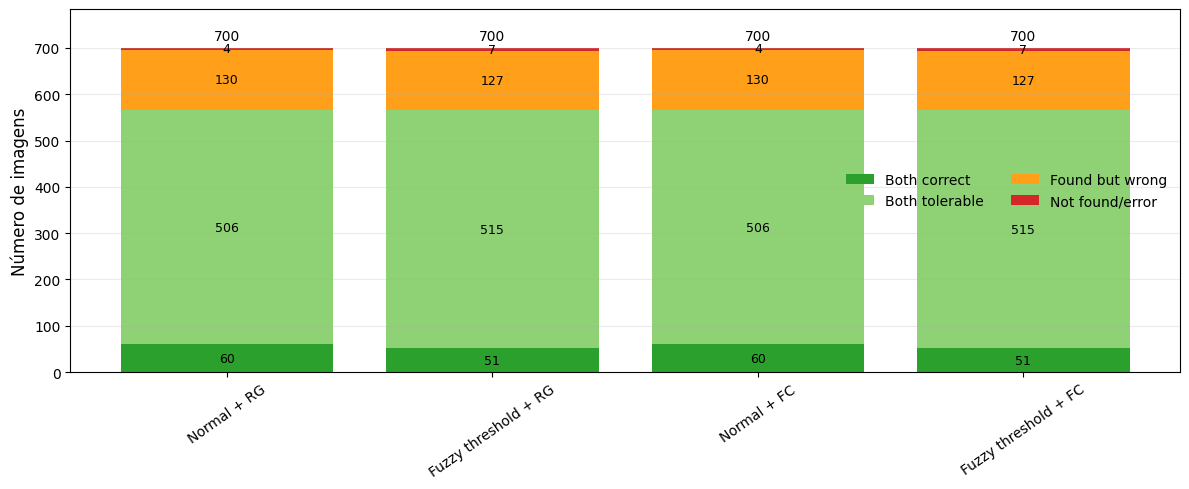

In [8]:
status_cols = ["both_correct_n", "both_tolerable_n", "found_wrong_n", "not_found_or_error_n"]
status_labels = ["Both correct", "Both tolerable", "Found but wrong", "Not found/error"]
colors = ["#2ca02c", "#8fd175", "#ff9f1a", "#d62728"]

fig, ax = plt.subplots(figsize=(12, 5))
x_labels = ostia_plot["variant_label"].astype(str)
bottom = np.zeros(len(ostia_plot))
for col, label, color in zip(status_cols, status_labels, colors):
    values = ostia_plot[col].to_numpy()
    bars = ax.bar(x_labels, values, bottom=bottom, label=label, color=color)
    for bar, value, base in zip(bars, values, bottom):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                base + value / 2,
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=9,
                color="black",
            )
    bottom += values

for x_pos, total in zip(range(len(x_labels)), bottom):
    ax.text(x_pos, total + max(bottom) * 0.015, f"{int(total)}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Número de imagens", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, max(bottom) * 1.12)
ax.tick_params(axis="x", rotation=35, labelsize=10)
ax.legend(ncol=2, frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_current_figure("ostia_status_by_variant.png")
plt.show()

## Dice Score por Variante

O gráfico abaixo mostra média e mediana do Dice arterial por variante.

In [9]:
dice_plot = summary_df.copy()
dice_plot["variant_label"] = pd.Categorical(
    dice_plot["variant_label"],
    [PRETTY_NAMES.get(name, name) for name in PREFERRED_ORDER],
    ordered=True,
)
dice_plot = dice_plot.sort_values("variant_label")

Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/dice_mean_median_by_variant.png


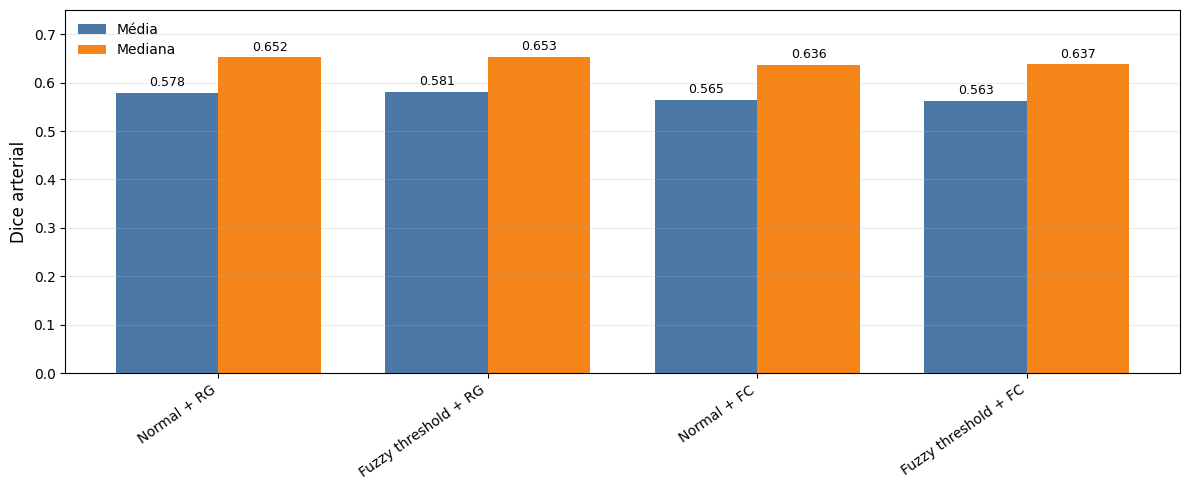

In [10]:
x = np.arange(len(dice_plot))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
mean_bars = ax.bar(x - width/2, dice_plot["mean_dice"], width, label="Média", color="#4c78a8")
median_bars = ax.bar(x + width/2, dice_plot["median_dice"], width, label="Mediana", color="#f58518")

for bars in [mean_bars, median_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.008,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(dice_plot["variant_label"].astype(str), rotation=35, ha="right")
ax.set_ylabel("Dice arterial", fontsize=12)
y_max = max(0.75, float(dice_plot[["mean_dice", "median_dice"]].max().max()) + 0.08)
ax.set_ylim(0, y_max)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_current_figure("dice_mean_median_by_variant.png")
plt.show()

## Comparação com Baseline

A célula abaixo usa `Normal + RG` como baseline e calcula o ganho/perda de Dice por imagem.

In [11]:
baseline_variant = "normal_rg"
baseline = results_df.loc[
    results_df["folder_variant"] == baseline_variant,
    ["IMG_ID", "artery_dice", "ostia_detection_status"],
].rename(columns={"artery_dice": "baseline_dice", "ostia_detection_status": "baseline_ostia_status"})

delta_rows = []
for variant in PREFERRED_ORDER:
    if variant == baseline_variant or variant not in set(results_df["folder_variant"]):
        continue
    current = results_df.loc[
        results_df["folder_variant"] == variant,
        ["IMG_ID", "artery_dice", "ostia_detection_status"],
    ].rename(columns={"artery_dice": "variant_dice", "ostia_detection_status": "variant_ostia_status"})
    merged = baseline.merge(current, on="IMG_ID", how="inner")
    merged["dice_delta"] = merged["variant_dice"] - merged["baseline_dice"]
    delta_rows.append({
        "folder_variant": variant,
        "variant_label": PRETTY_NAMES.get(variant, variant),
        "mean_delta": merged["dice_delta"].mean(),
        "median_delta": merged["dice_delta"].median(),
        "improved_ge_0_02": int((merged["dice_delta"] >= 0.02).sum()),
        "worse_le_minus_0_02": int((merged["dice_delta"] <= -0.02).sum()),
        "max_gain": merged["dice_delta"].max(),
        "max_loss": merged["dice_delta"].min(),
    })

delta_summary_df = pd.DataFrame(delta_rows).sort_values("mean_delta", ascending=False)

In [12]:
display(delta_summary_df.round({
    "mean_delta": 4,
    "median_delta": 4,
    "max_gain": 4,
    "max_loss": 4,
}))

,folder_variant,variant_label,mean_delta,median_delta,improved_ge_0_02,worse_le_minus_0_02,max_gain,max_loss
0,th_fuzzy_rg,Fuzzy threshold + RG,0.0025,0.0001,78,62,0.7976,-0.7349
1,normal_fc,Normal + FC,-0.0137,-0.0077,89,212,0.3198,-0.3780
2,th_fuzzy_fc,Fuzzy threshold + FC,-0.0156,-0.0094,123,256,0.7917,-0.7349


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/dice_delta_vs_normal_rg.png


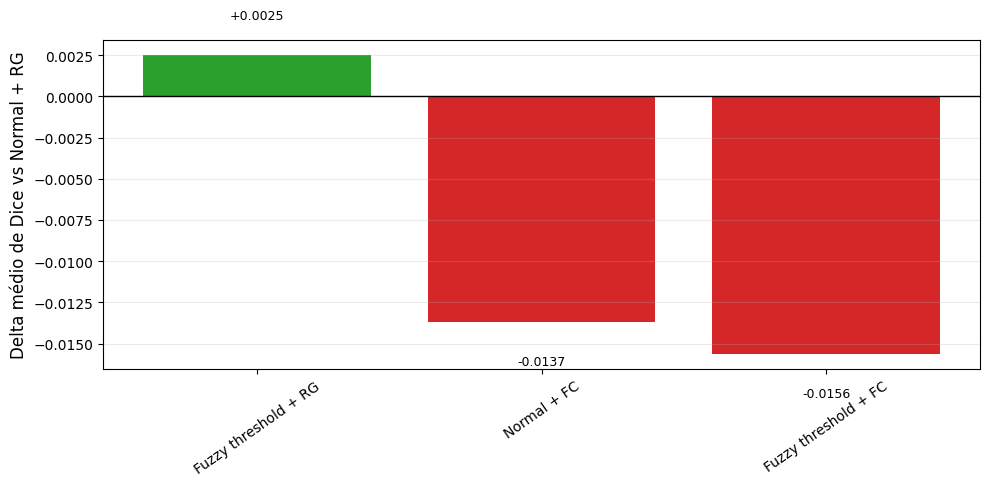

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_delta = delta_summary_df.copy()
colors = ["#2ca02c" if value >= 0 else "#d62728" for value in plot_delta["mean_delta"]]
bars = ax.bar(plot_delta["variant_label"], plot_delta["mean_delta"], color=colors)

for bar, value in zip(bars, plot_delta["mean_delta"]):
    va = "bottom" if value >= 0 else "top"
    offset = 0.002 if value >= 0 else -0.002
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f"{value:+.4f}",
        ha="center",
        va=va,
        fontsize=9,
    )

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Delta médio de Dice vs Normal + RG", fontsize=12)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35, labelsize=10)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_current_figure("dice_delta_vs_normal_rg.png")
plt.show()

## Maiores Variações por Comparação

As próximas células comparam pares específicos de variantes. Em cada comparação, o delta é calculado como `comparação - referência`. Valores positivos indicam que a segunda variante melhorou o Dice em relação à primeira.

In [14]:
PAIR_COMPARISONS = [
    ("normal_rg", "th_fuzzy_rg", "Threshold fuzzy vs normal, ambos com RG"),
    ("normal_fc", "th_fuzzy_fc", "Threshold fuzzy vs normal, ambos com FC"),
    ("normal_rg", "normal_fc", "FC vs RG com threshold normal"),
    ("th_fuzzy_rg", "th_fuzzy_fc", "FC vs RG com threshold fuzzy"),
]


def make_pair_delta(reference_variant: str, comparison_variant: str) -> pd.DataFrame:
    reference = results_df.loc[
        results_df["folder_variant"] == reference_variant,
        ["IMG_ID", "artery_dice", "ostia_detection_status", "artery_voxel_count"],
    ].rename(columns={
        "artery_dice": "reference_dice",
        "ostia_detection_status": "reference_ostia_status",
        "artery_voxel_count": "reference_artery_voxels",
    })
    comparison = results_df.loc[
        results_df["folder_variant"] == comparison_variant,
        ["IMG_ID", "artery_dice", "ostia_detection_status", "artery_voxel_count"],
    ].rename(columns={
        "artery_dice": "comparison_dice",
        "ostia_detection_status": "comparison_ostia_status",
        "artery_voxel_count": "comparison_artery_voxels",
    })
    pair_df = reference.merge(comparison, on="IMG_ID", how="inner")
    pair_df["dice_delta"] = pair_df["comparison_dice"] - pair_df["reference_dice"]
    pair_df["abs_delta"] = pair_df["dice_delta"].abs()
    pair_df["reference_variant"] = reference_variant
    pair_df["comparison_variant"] = comparison_variant
    return pair_df


def pair_summary(reference_variant: str, comparison_variant: str) -> pd.DataFrame:
    pair_df = make_pair_delta(reference_variant, comparison_variant)
    return pd.DataFrame([
        {
            "reference": PRETTY_NAMES.get(reference_variant, reference_variant),
            "comparison": PRETTY_NAMES.get(comparison_variant, comparison_variant),
            "n_images": len(pair_df),
            "mean_delta": pair_df["dice_delta"].mean(),
            "median_delta": pair_df["dice_delta"].median(),
            "comparison_better_ge_0_02": int((pair_df["dice_delta"] >= 0.02).sum()),
            "reference_better_ge_0_02": int((pair_df["dice_delta"] <= -0.02).sum()),
            "max_gain": pair_df["dice_delta"].max(),
            "max_loss": pair_df["dice_delta"].min(),
        }
    ])


def largest_pair_changes(reference_variant: str, comparison_variant: str, top_n: int = 15) -> pd.DataFrame:
    pair_df = make_pair_delta(reference_variant, comparison_variant)
    return pair_df.sort_values("abs_delta", ascending=False).head(top_n)[[
        "IMG_ID",
        "reference_dice",
        "comparison_dice",
        "dice_delta",
        "reference_ostia_status",
        "comparison_ostia_status",
        "reference_artery_voxels",
        "comparison_artery_voxels",
    ]]


def plot_largest_pair_changes(reference_variant: str, comparison_variant: str, title: str, filename: str, top_n: int = 15):
    pair_df = make_pair_delta(reference_variant, comparison_variant)
    plot_df = pair_df.sort_values("abs_delta", ascending=False).head(top_n).sort_values("dice_delta")
    colors = ["#2ca02c" if value >= 0 else "#d62728" for value in plot_df["dice_delta"]]
    fig, ax = plt.subplots(figsize=(12, 5.5))
    bars = ax.barh(plot_df["IMG_ID"].astype(str), plot_df["dice_delta"], color=colors)
    for bar, value in zip(bars, plot_df["dice_delta"]):
        ha = "left" if value >= 0 else "right"
        offset = 0.003 if value >= 0 else -0.003
        ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:+.3f}", va="center", ha=ha, fontsize=9)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Delta Dice: comparação - referência", fontsize=12)
    ax.set_ylabel("IMG_ID", fontsize=12)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()

### Threshold fuzzy vs normal, ambos com RG

In [15]:
display(pair_summary("normal_rg", "th_fuzzy_rg").round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_ge_0_02,reference_better_ge_0_02,max_gain,max_loss
0,Normal + RG,Fuzzy threshold + RG,700,0.0025,0.0001,78,62,0.7976,-0.7349


In [16]:
display(largest_pair_changes("normal_rg", "th_fuzzy_rg", top_n=15).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,reference_artery_voxels,comparison_artery_voxels
364,246,0.0000,0.7976,0.7976,found but incorrect,both correct,602.0,28495.0
510,33,0.7349,0.0000,-0.7349,both tolerable,found but incorrect,30683.0,1661.0
79,375,0.7277,0.0000,-0.7277,both tolerable,found but incorrect,25584.0,534.0
662,993,0.7174,0.0000,-0.7174,both correct,found but incorrect,41600.0,6009.0
198,650,0.0000,0.7079,0.7079,found but incorrect,both tolerable,0.0,28204.0
139,163,0.6793,0.0003,-0.6790,both tolerable,found but incorrect,26746.0,773.0
201,580,0.6655,0.0000,-0.6655,both tolerable,found but incorrect,24307.0,348.0
396,463,0.0000,0.6621,0.6621,found but incorrect,both tolerable,12090.0,43868.0
335,383,0.0000,0.6070,0.6070,found but incorrect,both tolerable,441.0,17043.0
255,39,0.6056,0.0000,-0.6056,both tolerable,not found,44055.0,NaN


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/largest_changes_th_fuzzy_rg_vs_normal_rg.png


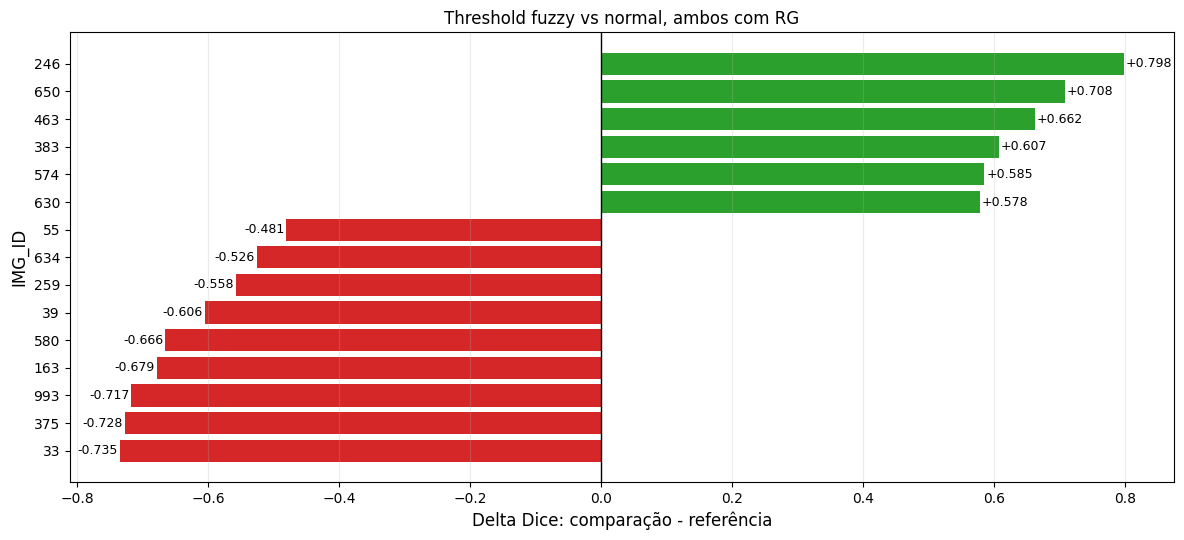

In [17]:
plot_largest_pair_changes(
    "normal_rg",
    "th_fuzzy_rg",
    "Threshold fuzzy vs normal, ambos com RG",
    "largest_changes_th_fuzzy_rg_vs_normal_rg.png",
    top_n=15,
)

### Threshold fuzzy vs normal, ambos com FC

In [18]:
display(pair_summary("normal_fc", "th_fuzzy_fc").round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_ge_0_02,reference_better_ge_0_02,max_gain,max_loss
0,Normal + FC,Fuzzy threshold + FC,700,-0.0019,0.0,65,72,0.7917,-0.7396


In [19]:
display(largest_pair_changes("normal_fc", "th_fuzzy_fc", top_n=15).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,reference_artery_voxels,comparison_artery_voxels
364,246,0.0000,0.7917,0.7917,found but incorrect,both correct,352.0,28715.0
510,33,0.7396,0.0000,-0.7396,both tolerable,found but incorrect,29058.0,1109.0
79,375,0.7313,0.0000,-0.7313,both tolerable,found but incorrect,25709.0,473.0
662,993,0.7188,0.0000,-0.7188,both correct,found but incorrect,41886.0,6314.0
198,650,0.0000,0.7148,0.7148,found but incorrect,both tolerable,181.0,27699.0
396,463,0.0000,0.6744,0.6744,found but incorrect,both tolerable,3309.0,38920.0
201,580,0.6601,0.0000,-0.6601,both tolerable,found but incorrect,24349.0,422.0
139,163,0.6280,0.0003,-0.6277,both tolerable,found but incorrect,24508.0,722.0
495,259,0.5588,0.0000,-0.5588,both tolerable,found but incorrect,26426.0,20688.0
613,74,0.5697,0.0116,-0.5581,both tolerable,both tolerable,12563.0,468.0


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/largest_changes_th_fuzzy_fc_vs_normal_fc.png


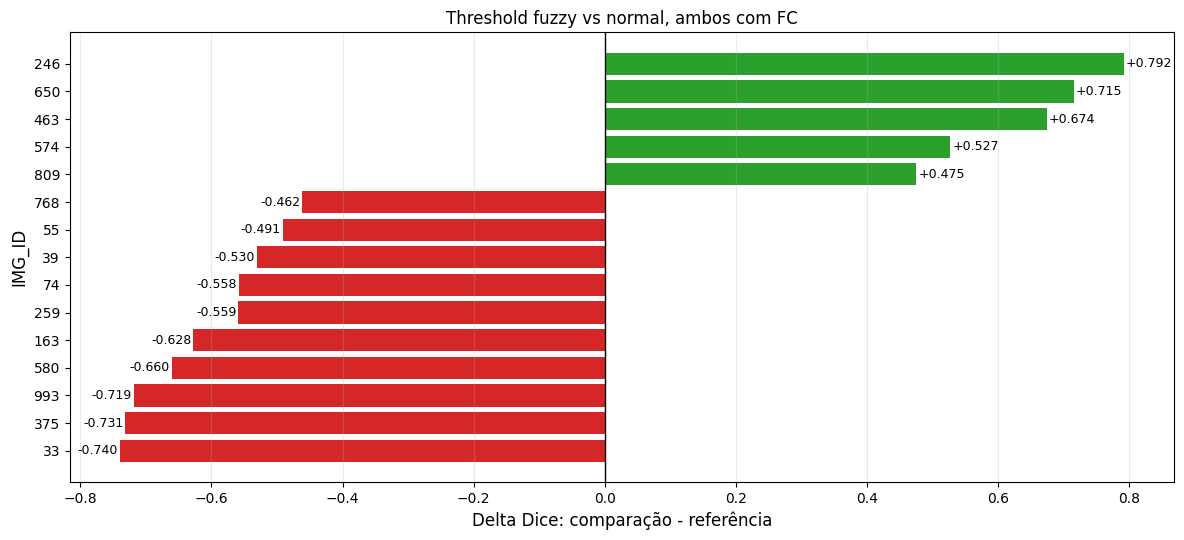

In [20]:
plot_largest_pair_changes(
    "normal_fc",
    "th_fuzzy_fc",
    "Threshold fuzzy vs normal, ambos com FC",
    "largest_changes_th_fuzzy_fc_vs_normal_fc.png",
    top_n=15,
)

### FC vs RG com threshold normal

In [21]:
display(pair_summary("normal_rg", "normal_fc").round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_ge_0_02,reference_better_ge_0_02,max_gain,max_loss
0,Normal + RG,Normal + FC,700,-0.0137,-0.0077,89,212,0.3198,-0.378


In [22]:
display(largest_pair_changes("normal_rg", "normal_fc", top_n=15).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,reference_artery_voxels,comparison_artery_voxels
42,38,0.6969,0.3190,-0.3780,both tolerable,both tolerable,18368.0,7123.0
19,386,0.5796,0.2262,-0.3534,both tolerable,both tolerable,30917.0,10229.0
352,904,0.3505,0.0000,-0.3505,found but incorrect,found but incorrect,14323.0,698.0
252,809,0.3542,0.0206,-0.3336,found but incorrect,found but incorrect,4952.0,685.0
75,359,0.1229,0.4427,0.3198,found but incorrect,found but incorrect,59333.0,6772.0
111,84,0.7388,0.4363,-0.3025,both tolerable,both tolerable,30711.0,14931.0
479,632,0.2509,0.5447,0.2937,both tolerable,both tolerable,157699.0,48847.0
633,745,0.3985,0.6907,0.2922,both tolerable,both tolerable,15564.0,33670.0
553,15,0.4641,0.7547,0.2906,both tolerable,both tolerable,14693.0,31027.0
243,818,0.7336,0.4462,-0.2874,both correct,both correct,22222.0,9346.0


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/largest_changes_normal_fc_vs_normal_rg.png


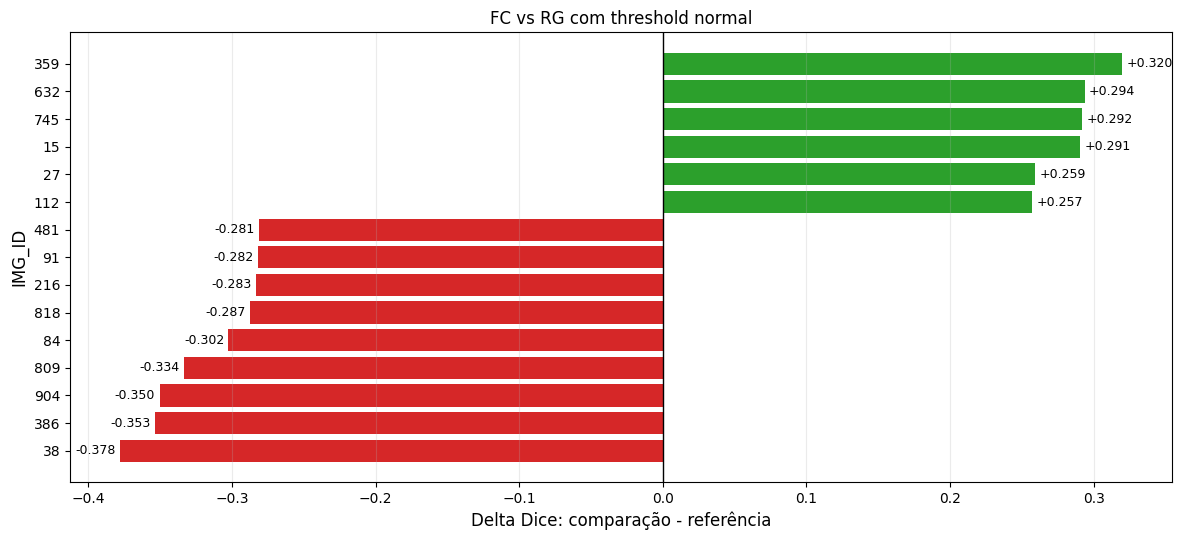

In [23]:
plot_largest_pair_changes(
    "normal_rg",
    "normal_fc",
    "FC vs RG com threshold normal",
    "largest_changes_normal_fc_vs_normal_rg.png",
    top_n=15,
)

### FC vs RG com threshold fuzzy

In [24]:
display(pair_summary("th_fuzzy_rg", "th_fuzzy_fc").round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_ge_0_02,reference_better_ge_0_02,max_gain,max_loss
0,Fuzzy threshold + RG,Fuzzy threshold + FC,700,-0.0181,-0.0076,76,224,0.496,-0.5563


In [25]:
display(largest_pair_changes("th_fuzzy_rg", "th_fuzzy_fc", top_n=15).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,reference_artery_voxels,comparison_artery_voxels
613,74,0.5679,0.0116,-0.5563,both tolerable,both tolerable,12179.0,468.0
160,634,0.0000,0.4960,0.4960,found but incorrect,found but incorrect,538.0,10044.0
589,256,0.6825,0.2360,-0.4465,both tolerable,both tolerable,36057.0,7817.0
137,292,0.7336,0.3485,-0.3852,both tolerable,both tolerable,29551.0,10509.0
42,38,0.6946,0.3172,-0.3774,both tolerable,both tolerable,18117.0,6915.0
468,571,0.6981,0.3497,-0.3484,found but incorrect,found but incorrect,47075.0,16868.0
410,563,0.2530,0.5838,0.3308,both tolerable,both tolerable,4020.0,12438.0
548,630,0.5780,0.2535,-0.3246,both tolerable,both tolerable,8013.0,2756.0
317,415,0.6160,0.3091,-0.3068,both tolerable,both tolerable,21778.0,8179.0
111,84,0.7390,0.4364,-0.3026,both tolerable,both tolerable,30662.0,14906.0


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/largest_changes_th_fuzzy_fc_vs_th_fuzzy_rg.png


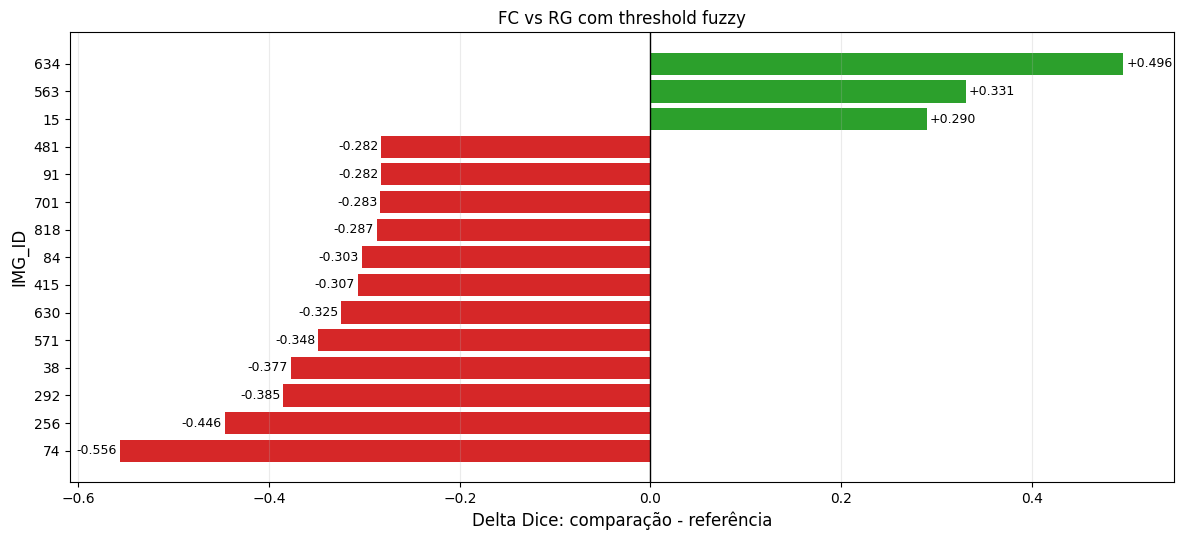

In [26]:
plot_largest_pair_changes(
    "th_fuzzy_rg",
    "th_fuzzy_fc",
    "FC vs RG com threshold fuzzy",
    "largest_changes_th_fuzzy_fc_vs_th_fuzzy_rg.png",
    top_n=15,
)

## Melhor RG vs Melhor FC

Esta comparação seleciona automaticamente a melhor variante RG e a melhor variante FC pelo ranking geral e mostra onde o FC mais ganha ou perde em relação ao RG.

In [27]:
def best_variant_by_suffix(suffix: str) -> str:
    candidates = ranking_df[ranking_df["folder_variant"].astype(str).str.endswith(suffix)]
    if candidates.empty:
        raise ValueError(f"Nenhuma variante encontrada com sufixo {suffix}")
    return candidates.iloc[0]["folder_variant"]

best_rg_variant = best_variant_by_suffix("_rg")
best_fc_variant = best_variant_by_suffix("_fc")
print(f"Melhor RG: {PRETTY_NAMES.get(best_rg_variant, best_rg_variant)}")
print(f"Melhor FC: {PRETTY_NAMES.get(best_fc_variant, best_fc_variant)}")

Melhor RG: Fuzzy threshold + RG
Melhor FC: Normal + FC


In [28]:
display(pair_summary(best_rg_variant, best_fc_variant).round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_ge_0_02,reference_better_ge_0_02,max_gain,max_loss
0,Fuzzy threshold + RG,Normal + FC,700,-0.0162,-0.01,108,254,0.7464,-0.7976


In [29]:
display(largest_pair_changes(best_rg_variant, best_fc_variant, top_n=20).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,reference_artery_voxels,comparison_artery_voxels
364,246,0.7976,0.0000,-0.7976,both correct,found but incorrect,28495.0,352.0
160,634,0.0000,0.7464,0.7464,found but incorrect,both tolerable,538.0,18957.0
510,33,0.0000,0.7396,0.7396,found but incorrect,both tolerable,1661.0,29058.0
79,375,0.0000,0.7313,0.7313,found but incorrect,both tolerable,534.0,25709.0
662,993,0.0000,0.7188,0.7188,found but incorrect,both correct,6009.0,41886.0
198,650,0.7079,0.0000,-0.7079,both tolerable,found but incorrect,28204.0,181.0
396,463,0.6621,0.0000,-0.6621,both tolerable,found but incorrect,43868.0,3309.0
201,580,0.0000,0.6601,0.6601,found but incorrect,both tolerable,348.0,24349.0
139,163,0.0003,0.6280,0.6277,found but incorrect,both tolerable,773.0,24508.0
335,383,0.6070,0.0000,-0.6070,both tolerable,found but incorrect,17043.0,294.0


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/largest_changes_best_fc_vs_best_rg.png


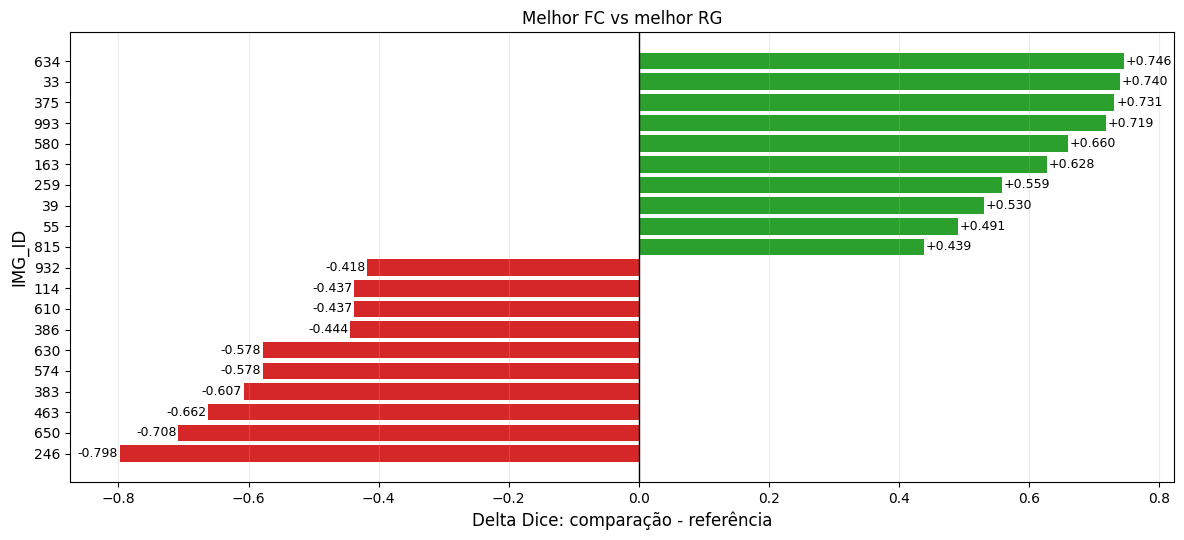

In [30]:
plot_largest_pair_changes(
    best_rg_variant,
    best_fc_variant,
    "Melhor FC vs melhor RG",
    "largest_changes_best_fc_vs_best_rg.png",
    top_n=20,
)